In [1]:
# Load libraries and the feature-engineered vehicle dataset.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_parquet('../data/processed/vehicles_features.parquet')
print(df.shape)

(50242, 43)


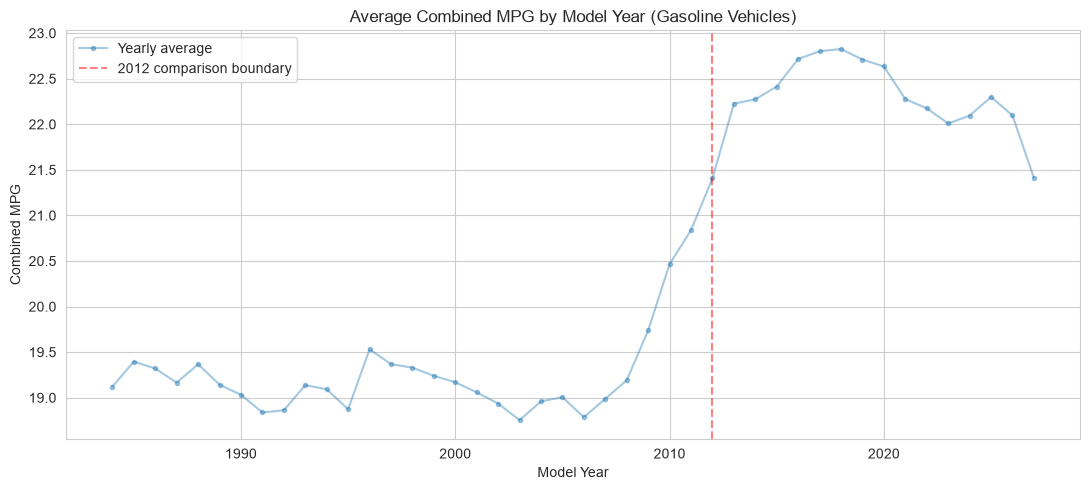

In [2]:
# Calculate average combined MPG by model year, gasoline vehicles only for a clean trend line
ice_trend = df[df['powertrain'] == 'Gasoline'].groupby('year')['comb08'].mean()
# Add a 3-year rolling average to show the underlying trend alongside the raw yearly values
# ice_trend_smooth = ice_trend.rolling(window=3, center=True).mean()

plt.figure(figsize=(11, 5))
ice_trend.plot(marker='o', markersize=3, alpha=0.4, label='Yearly average')
# ice_trend_smooth.plot(linewidth=2.5, label='3-year rolling average')
plt.title('Average Combined MPG by Model Year (Gasoline Vehicles)')
plt.ylabel('Combined MPG')
plt.xlabel('Model Year')
plt.axvline(2012, color='red', linestyle='--', alpha=0.5, label='2012 comparison boundary')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/charts/fleet_mpg_trend.png', dpi=150)
plt.show()

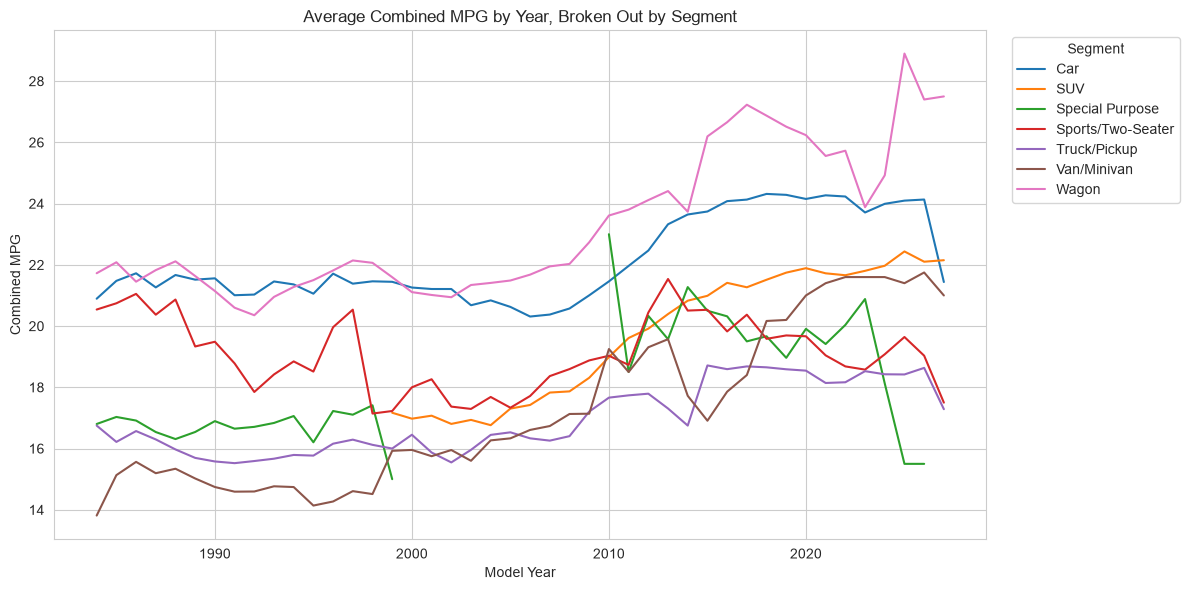

In [3]:
# Break the same trend down by vehicle segment to see which segments improved most
segment_trend = df[df['powertrain'] == 'Gasoline'].groupby(['year', 'segment'])['comb08'].mean().unstack()

segment_trend.plot(figsize=(12, 6))
plt.title('Average Combined MPG by Year, Broken Out by Segment')
plt.ylabel('Combined MPG')
plt.xlabel('Model Year')
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/charts/mpg_trend_by_segment.png', dpi=150)
plt.show()

In [4]:
# Rank manufacturers by average combined MPG over the last 10 model years, gasoline vehicles only,
# requiring at least 20 records so one-off/low-volume makes don't distort the ranking
recent_years = df['year'].max() - 9
ice_recent = df[(df['powertrain'] == 'Gasoline') & (df['year'] >= recent_years)].copy()

make_efficiency = (
    ice_recent.groupby('make')['comb08']
    .agg(['mean', 'count'])
    .query('count >= 20')
    .sort_values('mean', ascending=False)
)

print("Most fuel-efficient makes (last 10 years):")
print(make_efficiency.head(10))
print("\nLeast fuel-efficient makes (last 10 years):")
print(make_efficiency.tail(10))

Most fuel-efficient makes (last 10 years):
                 mean  count
make                        
Mitsubishi  28.467290    107
Honda       28.361217    263
MINI        28.088670    203
Mazda       28.017442    172
Fiat        27.480000     25
Hyundai     26.975945    291
Kia         26.225564    266
Volkswagen  26.114286    210
Subaru      25.938462    195
Toyota      25.105263    418

Least fuel-efficient makes (last 10 years):
                         mean  count
make                                
GMC                 18.342318    371
Dodge               18.317365    167
Maserati            18.242991    107
McLaren Automotive  17.933333     30
Ram                 17.694915     59
Aston Martin        17.423077     52
Bentley             15.854545     55
Ferrari             15.796875     64
Rolls-Royce         13.907895     76
Lamborghini         13.711538     52


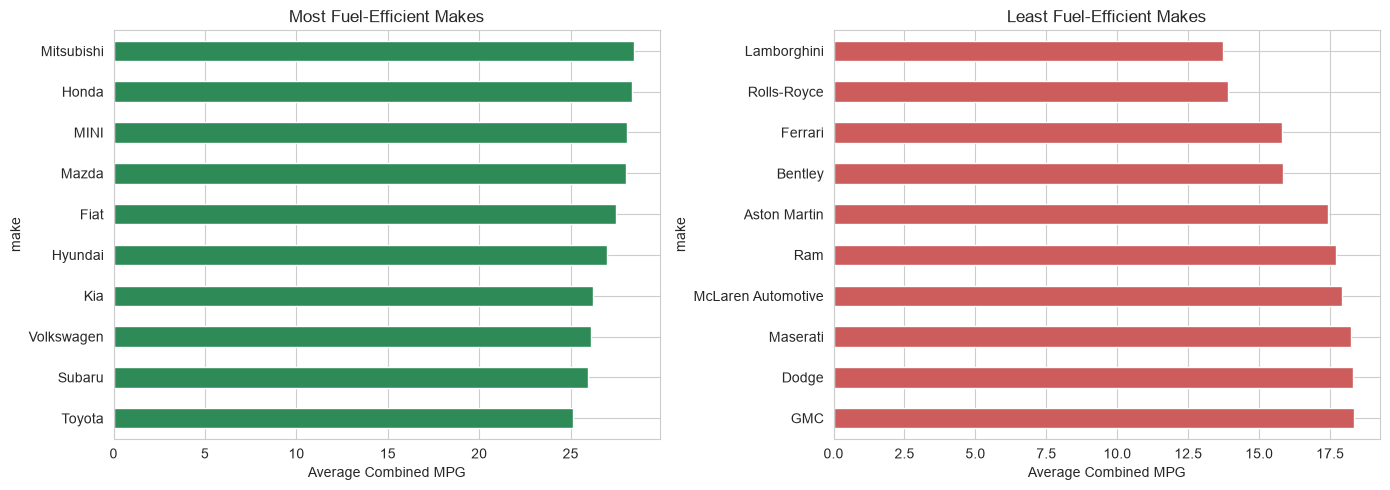

In [5]:
# Visualize the most and least efficient makes side by side
top10 = make_efficiency.head(10)
bottom10 = make_efficiency.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top10['mean'].sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Most Fuel-Efficient Makes')
axes[0].set_xlabel('Average Combined MPG')

bottom10['mean'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Least Fuel-Efficient Makes')
axes[1].set_xlabel('Average Combined MPG')

plt.tight_layout()
plt.savefig('../reports/charts/makes_most_least_efficient.png', dpi=150)
plt.show()

In [6]:
# Break down the model name

import re

def clean_model(model):
    model = str(model).strip()

    # Remove drivetrain/configuration suffixes at the end
    patterns = [
        r'\s+(2WD|4WD|AWD|FWD|RWD)$',
        r'\s+(2WD|4WD|AWD|FWD|RWD)\s+FFV$',
        r'\s+4motion$',
        r'\s+quattro$',
        r'\s+All4$',
        r'\s+ALL4$',
    ]

    for pattern in patterns:
        model = re.sub(pattern, '', model, flags=re.IGNORECASE)

    return model.strip()


ice_recent['model_clean'] = ice_recent['model'].apply(clean_model)

In [7]:
# Rank gasoline make/model groups, requiring at least five records per group.
model_efficiency = (
    ice_recent
    .groupby(['make', 'model_clean'])['comb08']
    .agg(['mean', 'count'])
    .query('count >= 5')
    .sort_values('mean', ascending=False)
)

print("Most fuel-efficient models (last 10 years):")
print(model_efficiency.head(15))
print("\nLeast fuel-efficient models (last 10 years):")
print(model_efficiency.tail(15))

Most fuel-efficient models (last 10 years):
                                       mean  count
make       model_clean                            
Mitsubishi Mirage                 37.615385     13
           Mirage G4              36.076923     13
Kia        Forte FE               34.666667      6
Mazda      2                      34.500000      8
Kia        Rio                    34.000000      8
Toyota     Corolla Hatchback      33.846154     13
           Yaris                  33.571429      7
Honda      Civic 4Dr              33.365854     41
           Fit                    33.333333      9
Hyundai    Accent                 33.333333      9
Chevrolet  Spark                  33.000000     10
Toyota     Corolla Hatchback XSE  33.000000      9
           Corolla                32.961538     26
Volkswagen Jetta                  32.666667     21
Honda      Civic 2Dr              32.625000     16

Least fuel-efficient models (last 10 years):
                                           

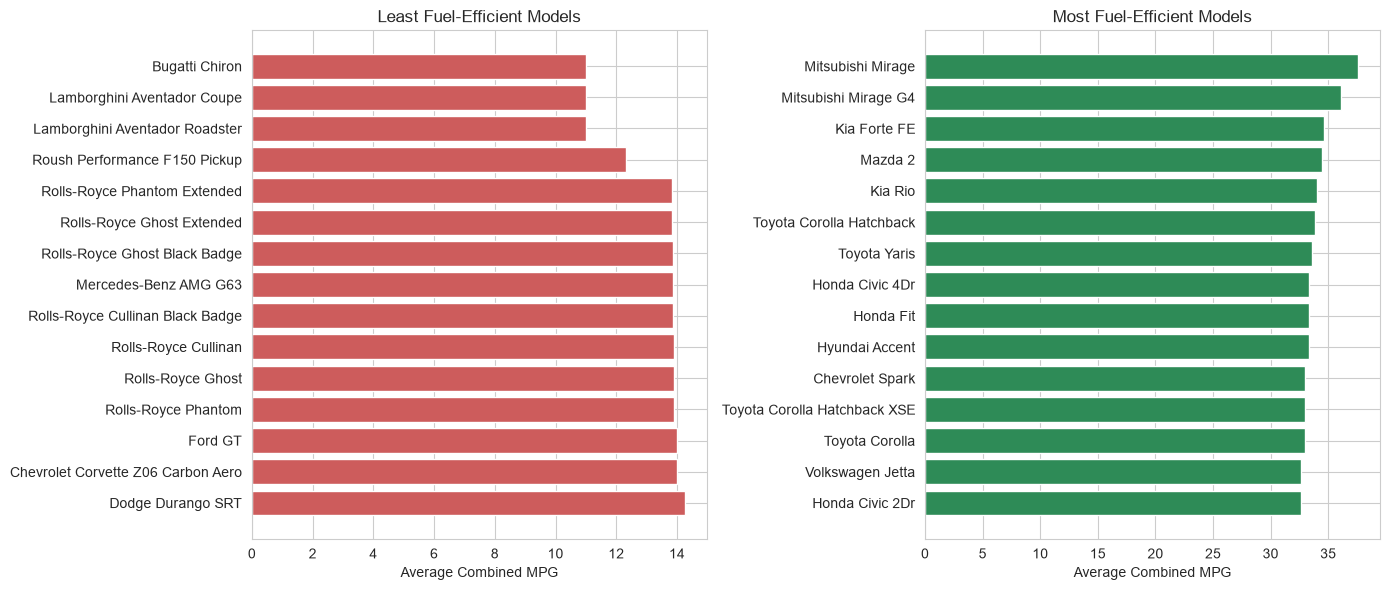

In [8]:
# Visualize the most and least efficient specific models, same pattern as the makes chart
model_top15 = model_efficiency.head(15)
model_bottom15 = model_efficiency.tail(15)

# Build readable labels combining make + model for the y-axis
model_top15_labels = [f"{make} {model}" for make, model in model_top15.index]
model_bottom15_labels = [f"{make} {model}" for make, model in model_bottom15.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Least efficient — lowest MPG at the TOP
axes[0].barh(
    model_bottom15_labels,
    model_bottom15['mean'],
    color='indianred'
)
axes[0].set_title('Least Fuel-Efficient Models')
axes[0].set_xlabel('Average Combined MPG')

# Most efficient — keep original ordering
axes[1].barh(
    model_top15_labels[::-1],
    model_top15['mean'][::-1],
    color='seagreen'
)
axes[1].set_title('Most Fuel-Efficient Models')
axes[1].set_xlabel('Average Combined MPG')

plt.tight_layout()
plt.savefig('../reports/charts/models_most_least_efficient.png', dpi=150)
plt.show()

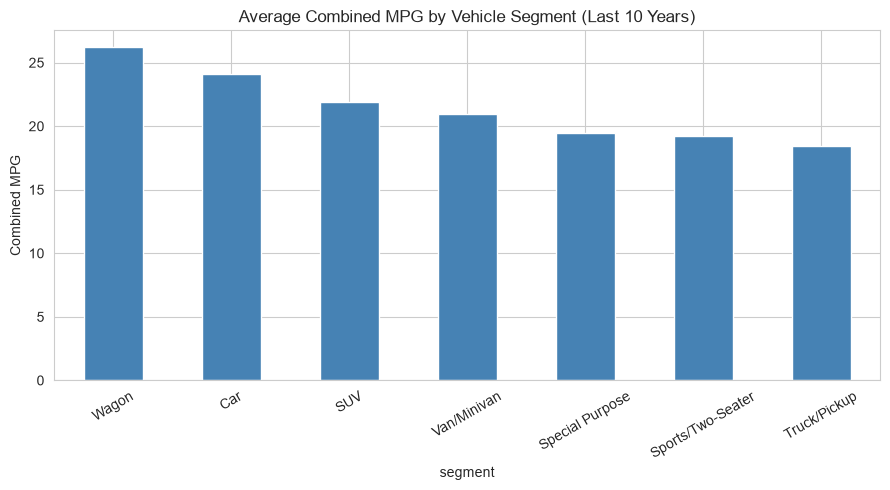

In [9]:
# Rank the simplified vehicle segments by average combined MPG, most to least efficient
segment_efficiency = ice_recent.groupby('segment')['comb08'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
segment_efficiency.plot(kind='bar', color='steelblue')
plt.title('Average Combined MPG by Vehicle Segment (Last 10 Years)')
plt.ylabel('Combined MPG')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/charts/mpg_by_segment.png', dpi=150)
plt.show()

In [10]:
# Check sample sizes behind the drivetrain x cylinder pivot, since small groups can produce misleading averages
spec_counts = ice_recent.pivot_table(values='comb08', index='cylinders', columns='drive', aggfunc='count')
print(spec_counts)

drive      4-Wheel Drive  All-Wheel Drive  Front-Wheel Drive  \
cylinders                                                      
3.0                  2.0             58.0              131.0   
4.0                316.0           1287.0             1501.0   
5.0                  NaN             13.0                NaN   
6.0                267.0            925.0              293.0   
8.0                489.0            373.0                4.0   
10.0                 NaN             24.0                NaN   
12.0                 1.0             92.0                NaN   
16.0                 NaN             14.0                NaN   

drive      Part-time 4-Wheel Drive  Rear-Wheel Drive  
cylinders                                             
3.0                            2.0               NaN  
4.0                          105.0             582.0  
5.0                            NaN               NaN  
6.0                          203.0             820.0  
8.0                          

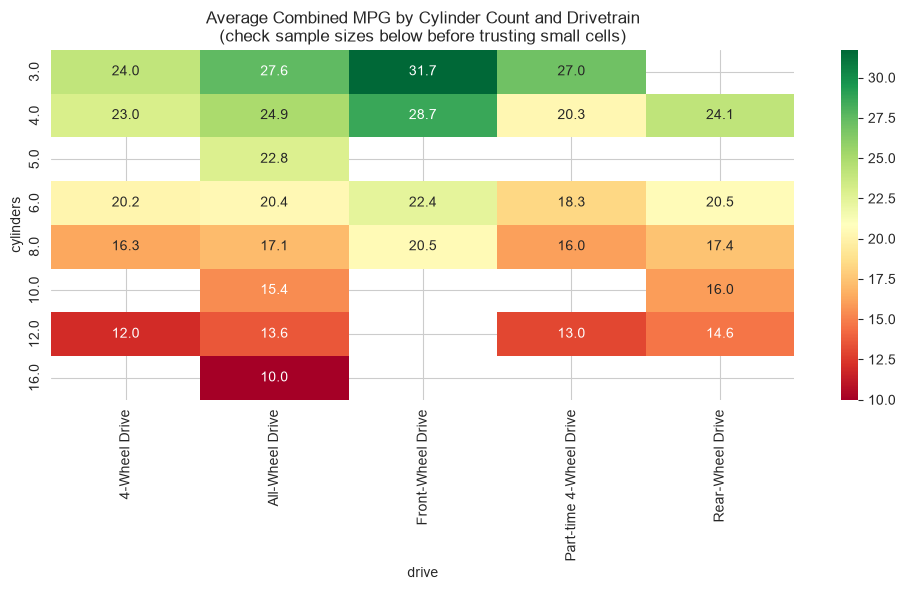

Sample sizes behind each cell (low counts = less reliable):
drive      4-Wheel Drive  All-Wheel Drive  Front-Wheel Drive  \
cylinders                                                      
3.0                  2.0             58.0              131.0   
4.0                316.0           1287.0             1501.0   
5.0                  NaN             13.0                NaN   
6.0                267.0            925.0              293.0   
8.0                489.0            373.0                4.0   
10.0                 NaN             24.0                NaN   
12.0                 1.0             92.0                NaN   
16.0                 NaN             14.0                NaN   

drive      Part-time 4-Wheel Drive  Rear-Wheel Drive  
cylinders                                             
3.0                            2.0               NaN  
4.0                          105.0             582.0  
5.0                            NaN               NaN  
6.0                     

In [11]:
# Build a pivot table showing average MPG across combinations of drivetrain and cylinder count
spec_pivot = ice_recent.pivot_table(values='comb08', index='cylinders', columns='drive', aggfunc='mean')
# Also compute counts so low-sample cells can be flagged rather than trusted at face value
spec_counts = ice_recent.pivot_table(values='comb08', index='cylinders', columns='drive', aggfunc='count')

plt.figure(figsize=(10, 6))
sns.heatmap(spec_pivot, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Average Combined MPG by Cylinder Count and Drivetrain\n(check sample sizes below before trusting small cells)')
plt.tight_layout()
plt.savefig('../reports/charts/mpg_by_specs_heatmap.png', dpi=150)
plt.show()

print("Sample sizes behind each cell (low counts = less reliable):")
print(spec_counts)

In [12]:
# Rank battery electric models separately by MPGe, since it's not on the same scale as gasoline MPG
bev_efficiency = (
    df[df['powertrain'] == 'BEV']
    .groupby(['make', 'model'])['comb08']
    .mean()
    .sort_values(ascending=False)
)
print("Most efficient EV models (by MPGe):")
print(bev_efficiency.head(10))

Most efficient EV models (by MPGe):
make     model                                  
Lucid    Air Pure RWD with 19 inch wheels           143.0
Tesla    Model 3 Standard Range Plus RWD            142.0
Hyundai  Ioniq 6 Long range RWD (18 inch Wheels)    140.0
Lucid    Air Pure AWD with 19 inch wheels           140.0
Tesla    Model 3 Standard RWD                       139.0
         Model Y Standard RWD (18in Wheels)         138.0
         Model 3 Long Range RWD                     137.0
         Model 3 Premium RWD                        137.0
         Model 3 Standard Range Plus                137.0
Hyundai  Ioniq 6 Standard Range RWD                 135.0
Name: comb08, dtype: float64


In [13]:
# # Quick all-time min/max highlight across the full dataset, for a one-line "did you know" stat
# most_efficient_ever = df.loc[df['comb08'].idxmax(), ['make', 'model', 'year', 'comb08', 'powertrain']]
# least_efficient_ever = df.loc[df[df['powertrain'] == 'Gasoline']['comb08'].idxmin(), ['make', 'model', 'year', 'comb08']]

# print("Most efficient vehicle ever recorded:\n", most_efficient_ever)
# print("\nLeast efficient gasoline vehicle ever recorded:\n", least_efficient_ever)

## Supporting context: electrification in vehicle records

Shares count database configurations, not sales. First appearances reflect this snapshot, not global launch dates. Latest model years may be incomplete.


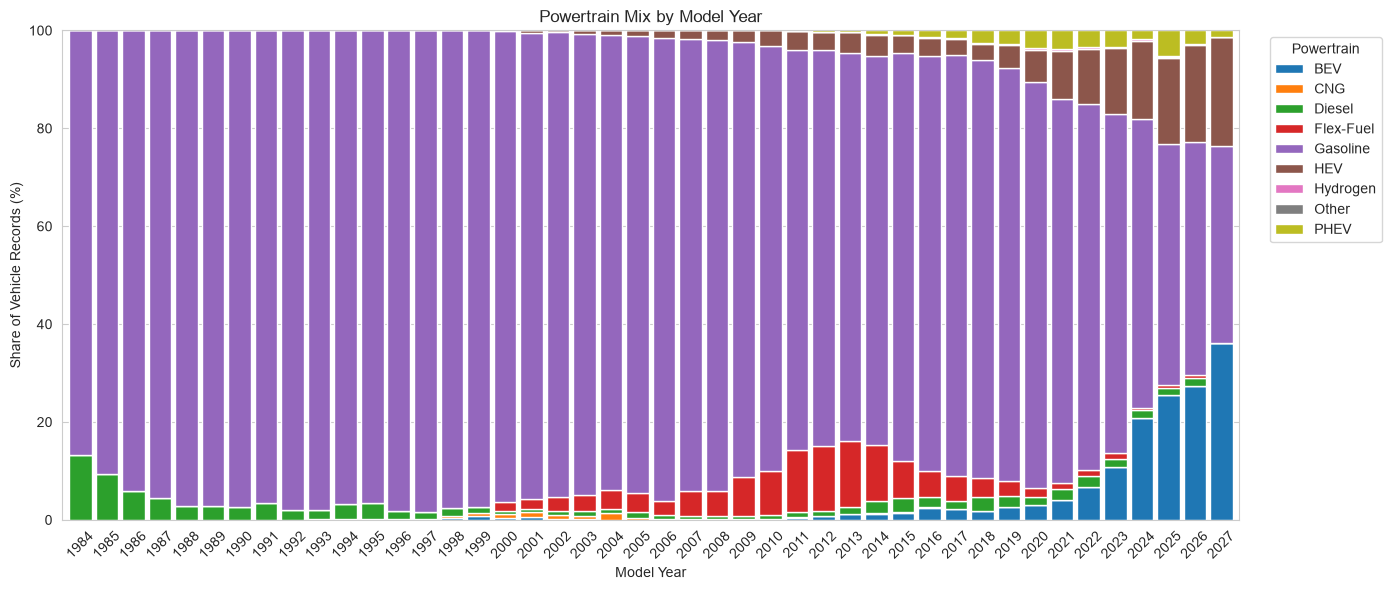

In [14]:
# Calculate the percentage share of each powertrain for every model year.

powertrain_by_year = (
    pd.crosstab(df['year'], df['powertrain'], normalize='index') * 100
)

ax = powertrain_by_year.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    width=0.85
)

ax.set_title('Powertrain Mix by Model Year')
ax.set_ylabel('Share of Vehicle Records (%)')
ax.set_xlabel('Model Year')
ax.legend(
    title='Powertrain',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/powertrain_mix_by_year_stacked_bar.png', dpi=150)
plt.show()

In [15]:
# Find the earliest model year in which each non-gasoline powertrain appears.
# Noting that this only counts for car appeared in the dataset only and may not 
# reflect the real world.

first_appearance = (
    df[df['powertrain'] != 'Gasoline']
    .groupby('powertrain')['year']
    .min()
    .sort_values()
)
print(first_appearance)

powertrain
Diesel       1984
CNG          1993
BEV          1998
Flex-Fuel    2000
HEV          2000
PHEV         2011
Hydrogen     2014
Other        2025
Name: year, dtype: int64


In [16]:
# Identify each manufacturer's earliest recorded HEV, PHEV, or BEV.

electrified = df[df['powertrain'].isin(['HEV', 'PHEV', 'BEV'])]

first_year = (
    electrified
    .groupby('make')['year']
    .min()
    .reset_index()
)

first_by_maker = (
    electrified
    .merge(first_year, on=['make', 'year'])
    .sort_values(['year', 'make'])
    .drop_duplicates('make')
)

top15 = first_by_maker.head(15)
print(first_by_maker.head(15))

       id  year       make                      model  \
22  30976  1998  Chevrolet               S10 Electric   
21  30975  1998      Honda                    EV Plus   
19  30973  1999      Dodge  Caravan/Grand Caravan 2WD   
17  30971  1999       Ford          Ranger Pickup 2WD   
15  30968  1999        GMC                        EV1   
20  30974  1999   Plymouth  Voyager/Grand Voyager 2WD   
0   16423  2000     Nissan                   Altra EV   
1   16424  2000     Toyota                    RAV4 EV   
2   22431  2006      Lexus                RX 400h 2WD   
4   22553  2006      Mazda         Tribute Hybrid 4WD   
5   22560  2006    Mercury         Mariner Hybrid 4WD   
6   23397  2007     Saturn                 Vue Hybrid   
24  30978  2008       MINI                      MiniE   
8   25599  2009   Cadillac        Escalade Hybrid 2WD   
9   26322  2009   Chrysler                  Aspen HEV   

                         VClass                       drive  \
22      Small Pickup Tru

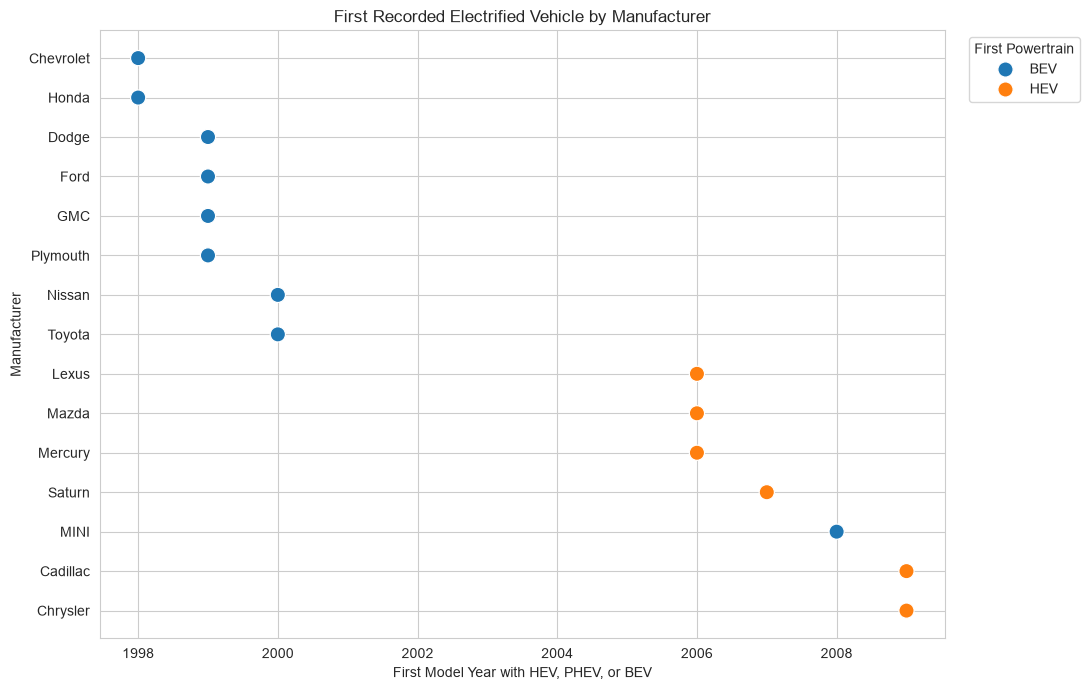

In [17]:
# Plot the earliest electrification year for the 15 earliest manufacturers.

top15 = first_by_maker.head(15).sort_values('year')

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=top15,
    x='year',
    y='make',
    hue='powertrain',
    s=120
)

plt.title('First Recorded Electrified Vehicle by Manufacturer')
plt.xlabel('First Model Year with HEV, PHEV, or BEV')
plt.ylabel('Manufacturer')

plt.legend(title='First Powertrain', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../reports/manufacturer_electrification_timeline.png', dpi=150)
plt.show()

In [18]:
# Calculate average BEV range by year while keeping the yearly sample size.

bev = df[df['powertrain'] == 'BEV']

range_by_year = (
    bev.groupby('year')['range']
    .agg(['mean', 'count'])
    .round(2)
)

print(range_by_year)

        mean  count
year               
1998   62.00      3
1999   69.43      7
2000   73.25      4
2001   47.60      5
2002   66.50      2
2003   95.00      1
2008  100.00      1
2011   73.25      4
2012  105.62      8
2013  106.14     14
2014  114.80     15
2015  157.39     18
2016  185.10     31
2017  186.90     30
2018  197.08     24
2019  229.23     35
2020  260.34     38
2021  246.88     51
2022  274.81     89
2023  276.40    144
2024  286.77    266
2025  291.95    326
2026  302.13    321
2027  314.52    135


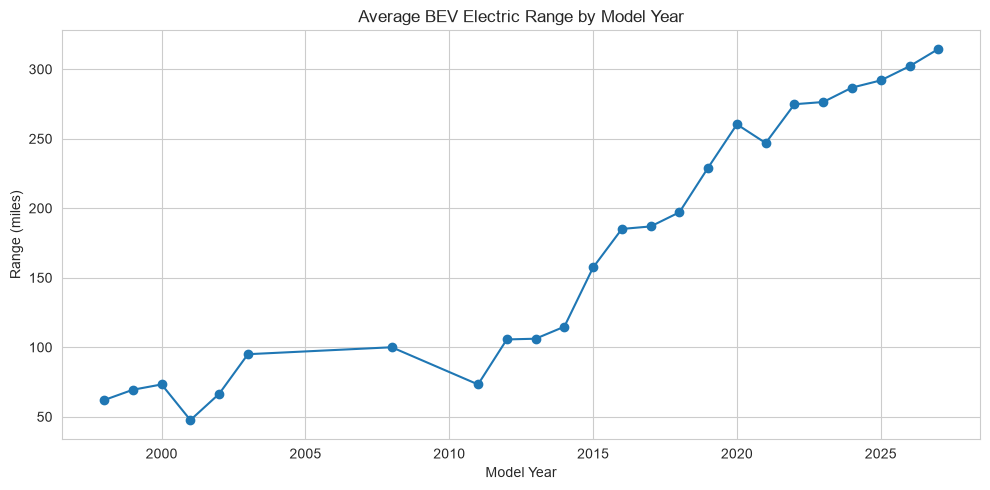

In [19]:
# Plot how average BEV electric range has changed across model years.
plt.figure(figsize=(10, 5))

range_by_year['mean'].plot(marker='o')

plt.title('Average BEV Electric Range by Model Year')
plt.ylabel('Range (miles)')
plt.xlabel('Model Year')

plt.tight_layout()
plt.savefig('../reports/bev_range_by_year.png', dpi=150)
plt.show()

                 mean  median  count
powertrain                          
BEV         93.415394    92.0   1572
Hydrogen    64.023810    65.0     42
Other       39.000000    39.0      2
HEV         29.616124    27.0   1873
PHEV        28.158837    26.0    447
Diesel      23.984733    23.0   1310
Gasoline    20.268293    20.0  43378
Flex-Fuel   18.035761    17.0   1538
CNG         17.437500    13.0     80


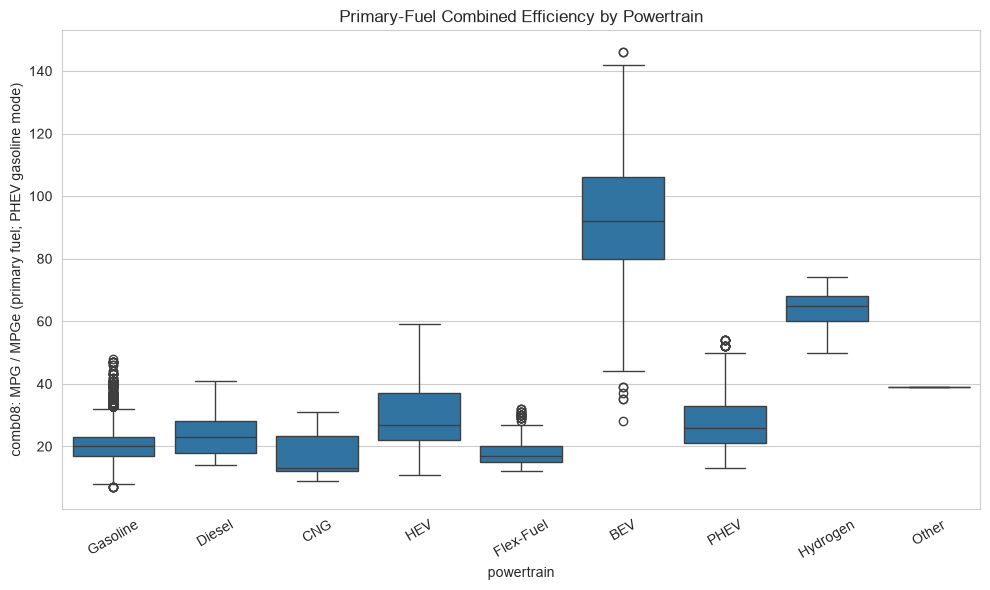

In [20]:
# Compare the reported EPA combined efficiency metric across powertrains.

comb_by_powertrain = df.groupby('powertrain')['comb08'].agg(['mean', 'median', 'count'])
print(comb_by_powertrain.sort_values('mean', ascending=False))

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='powertrain', y='comb08')
plt.title('Primary-Fuel Combined Efficiency by Powertrain')
plt.ylabel('comb08: MPG / MPGe (primary fuel; PHEV gasoline mode)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/mpg_by_powertrain.png', dpi=150)
plt.show()

segment
Wagon                63.01
SUV                  53.94
Special Purpose      52.94
Car                  52.09
Van/Minivan          47.83
Truck/Pickup         38.32
Sports/Two-Seater    19.05
Name: is_electrified, dtype: float64


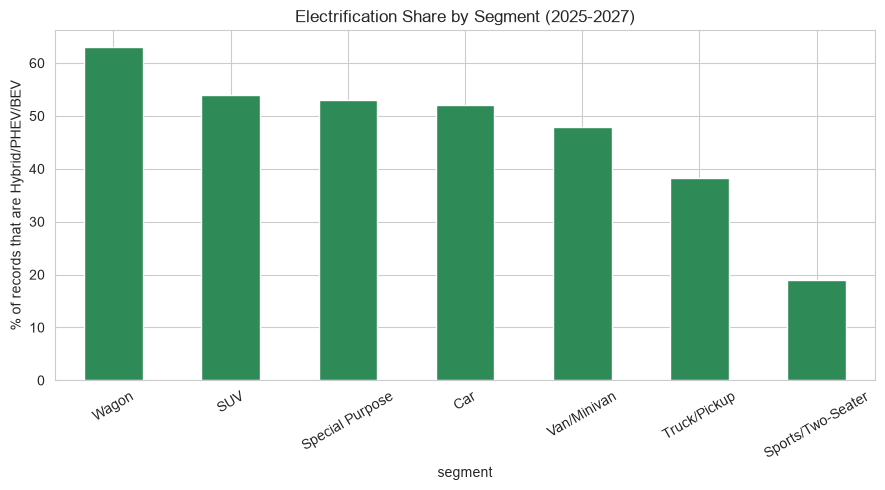

In [21]:
# Measure the share of electrified vehicles within each segment in 2-3 recent years.

recent = df[df['year'] >= df['year'].max() - 2]

electrified_share = (
    recent.assign(is_electrified=recent['powertrain'].isin(['HEV', 'PHEV', 'BEV']))
    .groupby('segment')['is_electrified']
    .mean() * 100
    
).sort_values(ascending=False).round(2)

print(electrified_share)

plt.figure(figsize=(9, 5))
electrified_share.plot(kind='bar', color='seagreen')
plt.ylabel('% of records that are Hybrid/PHEV/BEV')
plt.title(f'Electrification Share by Segment ({int(recent["year"].min())}-{int(recent["year"].max())})')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/electrification_share_by_segment.png', dpi=150)
plt.show()

PHEV alternate-fuel (electricity) range by year:
           mean  count
year                  
2011  35.000000      1
2012  26.333333      3
2013  22.250000      4
2014  26.100000     10
2015  24.000000     12
2016  23.611111     18
2017  24.894737     19
2018  25.529412     34
2019  27.333333     36
2020  26.711111     45
2021  27.880000     50
2022  24.704545     44
2023  28.090909     44
2024  30.130435     23
2025  27.940299     67
2026  28.187500     32
2027  28.200000      5


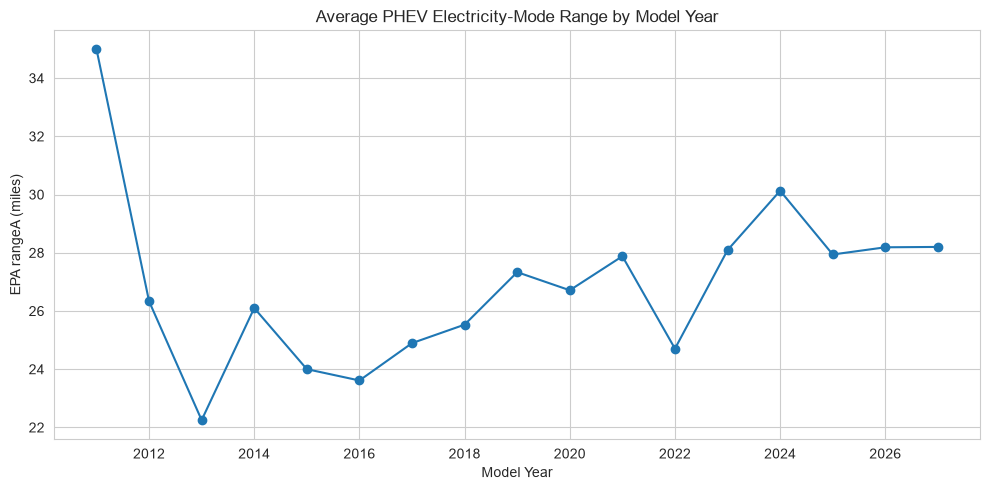

In [22]:
# Electricity is fuelType2 for these PHEVs; rangeA is its EPA range.
# The primary range field is not the PHEV electric-range measure.
phev = df[(df['powertrain'] == 'PHEV') & (df['fuelType2'] == 'Electricity')]
phev_range_trend = phev.groupby('year')['rangeA'].agg(['mean', 'count'])
print('PHEV alternate-fuel (electricity) range by year:')
print(phev_range_trend)
plt.figure(figsize=(10, 5))
plt.plot(phev_range_trend.index, phev_range_trend['mean'], marker='o')
plt.title('Average PHEV Electricity-Mode Range by Model Year')
plt.ylabel('EPA rangeA (miles)')
plt.xlabel('Model Year')
plt.tight_layout()
plt.savefig('../reports/phev_range_trend.png', dpi=150)
plt.show()


note: 
- avg cylinder/drivetrain plot still misleading, ignore if samples are too low